In [1]:
from ProjectFunctions import *

# Comparing conductance to Affinity Matrix Eigenvalue gap

# This notebook also will show eigenvector overlap with clusters simultaneously

In [12]:
%%time
#create necessary lists to contain the values over the range of h vals
length = 8
hvals = np.arange(0.01, 3, .1)

combinations = []

vec1_S_overlap_list = []
vec1_T_overlap_list = []

vec2_S_overlap_list = []
vec2_T_overlap_list = []

vec3_S_overlap_list = []
vec3_T_overlap_list = []

maxgaplist = []
secondgaplist = []
thirdgaplist = []
conductancelist = []

S_overlap_list = []
T_overlap_list = []
# Generate all possible pairs of positions
for i in range(length):
    for j in range(i + 1, length):
        combinations.append([i, j])

#Generate the instance not dependent on h val
Hfield = sg_field(length)
jij = generate_jij(length, 14, 5001)
Hint, Hintdiag = sg_interaction(length, jij)
#for ever h value, generate the full instance
for h in hvals:
    H = Hint + (h * Hfield)
    E, psi = H.groundstate()

#calculate mutual information and mutual information distance
    minfolist = []
    distlist = []
    for i in range(length):
        for j in range(i + 1, length):
            minfo, distance = mutual_info(length, psi, [i], [j])
            distlist.append(distance)
            minfolist.append(minfo)
    distdict.update({h: distlist})
    minfodict.update({h: minfolist})
    
   
    # Create a networkx graph
    G = nx.Graph()

    # Add edges with weights
    for [i, j], dist in zip(combinations, distlist):
        G.add_edge(i, j, weight = dist)


    #calculate the shortest path lengths as well as the nodes to follow for shortest paths
    path = dict(nx.all_pairs_dijkstra_path(G, cutoff=None, weight='weight'))
    lengths = dict(nx.all_pairs_dijkstra_path_length(G, cutoff=None, weight='weight'))
    
    #generate affinity matrix and use sklearn to identify clusters
    clusterObj = skl.cluster.SpectralClustering(n_clusters = 2, affinity = 'precomputed')
    affmat = create_affinity_matrix(length, combinations, minfodict[h])
    clusters = clusterObj.fit_predict(affmat)

    #find eigenvalue gaps from affinity matrix and append to list
    num_clusters, max_gap, max_gap_norm, second_gap, third_gap = affmat_analysis(affmat)
    maxgaplist.append(max_gap_norm)
    secondgaplist.append(second_gap)
    thirdgaplist.append(third_gap)
    
    #calculate conductance and append to list
    conductance = graph_conductance(affmat, clusters)
    conductancelist.append(conductance)
    
    #rearrange the affinity matrix to block diagonal by cluster
    new_order, new_affmat = rearrange_affmat(affmat, clusters)
    
    #calculate eigenvector overlaps
    overlaps1 = eigenvector_overlap_rearranged(new_affmat, 0)
    overlaps2 = eigenvector_overlap_rearranged(new_affmat, 1)
    overlaps3 = eigenvector_overlap_rearranged(new_affmat, 2)
    
    #add overlaps to their lists
    vec1_S_overlap_list.append(overlaps1[0])
    vec1_T_overlap_list.append(overlaps1[1])

    vec2_S_overlap_list.append(overlaps2[0])
    vec2_T_overlap_list.append(overlaps2[1])
    
    vec3_S_overlap_list.append(overlaps3[0])
    vec3_T_overlap_list.append(overlaps3[1])


C:\Users\danny\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\danny\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\danny\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\danny\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

C:\Users\danny\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


CPU times: total: 2min 53s
Wall time: 37.8 s


C:\Users\danny\anaconda3\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\danny\anaconda3\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


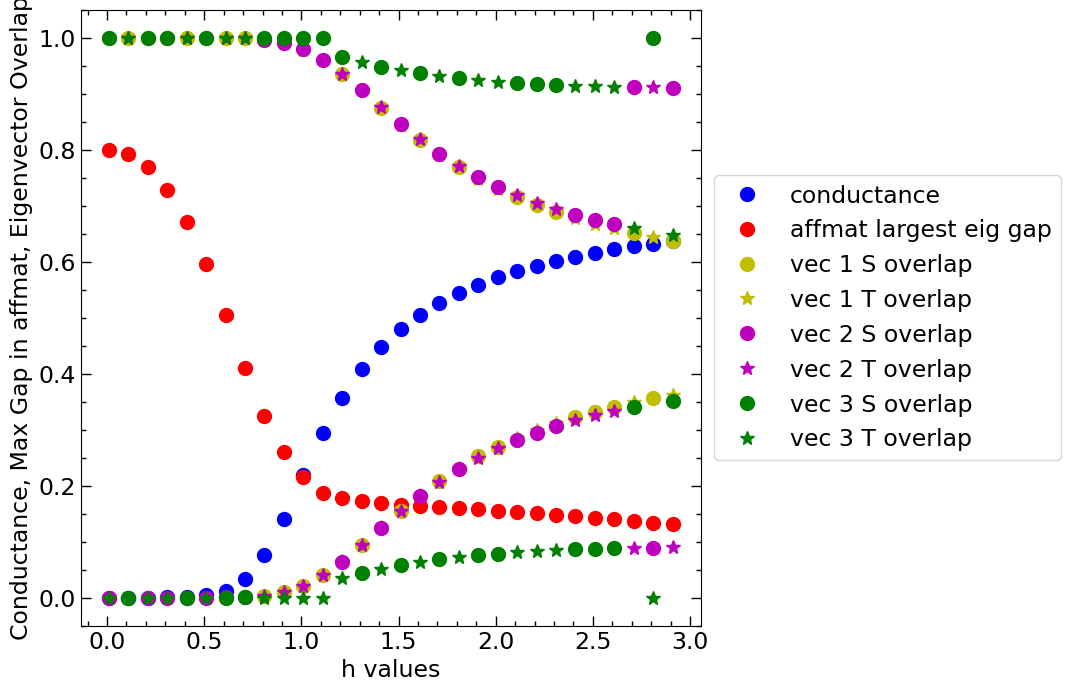

In [13]:
#create the plot
fig, ax = plt.subplots(figsize=(8,8))
plt.rcParams.update({'font.size': 17})
# label the axes
ax.set_xlabel("h values")
ax.set_ylabel("Conductance, Max Gap in affmat, Eigenvector Overlap")

# set the tick mark parameters
ax.minorticks_on()
ax.tick_params(which='both',direction="in",width=1)
ax.tick_params(which='major',length=7)
ax.tick_params(which='minor',length=3.5)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')


#plot conductance and affinity matrix eigenvalue gaps
p1 = plt.plot(hvals, conductancelist, 'ob', markersize = 10, label = 'conductance')
p2 = plt.plot(hvals, maxgaplist, 'or', markersize = 10, label = 'affmat largest eig gap')
#p3 = plt.plot(hvals, secondgaplist, 'og', markersize = 10, label = 'affmat 2nd eig gap')
#p4 = plt.plot(hvals, thirdgaplist, 'ok', markersize = 10, label = 'affmat 3rd eig gap')

#plot the eigenvector overlaps
p3 = plt.plot(hvals, vec1_S_overlap_list, 'oy', markersize = 10, label = 'vec 1 S overlap')
p4 = plt.plot(hvals, vec1_T_overlap_list, '*y', markersize = 10, label = 'vec 1 T overlap')

p5 = plt.plot(hvals, vec2_S_overlap_list, 'om', markersize = 10, label = 'vec 2 S overlap')
p6 = plt.plot(hvals, vec2_T_overlap_list, '*m', markersize = 10, label = 'vec 2 T overlap')

p7 = plt.plot(hvals, vec3_S_overlap_list, 'og', markersize = 10, label = 'vec 3 S overlap')
p8 = plt.plot(hvals, vec3_T_overlap_list, '*g', markersize = 10, label = 'vec 3 T overlap')
plt.legend(bbox_to_anchor = (1.6,.5), loc = 'right')
#plt.axis([1.2, 1.3, 0.2, 0.6])
#plt.savefig("conductance_analysis_degen4_fix.pdf")
plt.show()

# This is a busy graph, this cell plots them separately

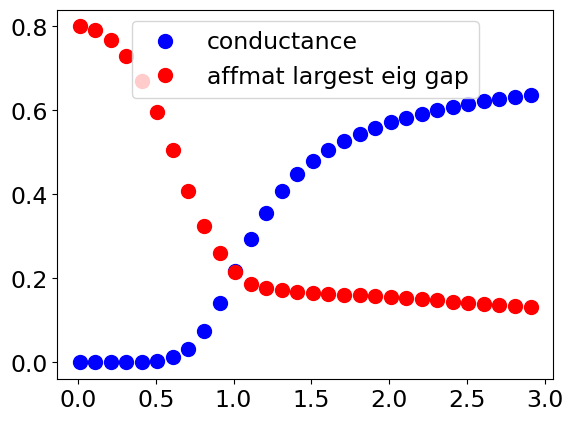

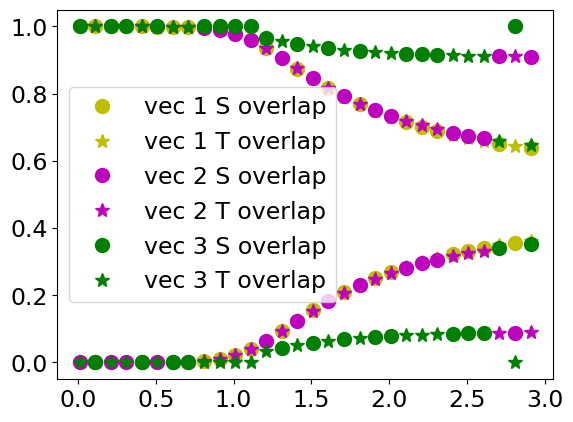

In [14]:
#plot conductance and affinity matrix eigenvalue gaps
p1 = plt.plot(hvals, conductancelist, 'ob', markersize = 10, label = 'conductance')
p2 = plt.plot(hvals, maxgaplist, 'or', markersize = 10, label = 'affmat largest eig gap')
#p3 = plt.plot(hvals, secondgaplist, 'og', markersize = 10, label = 'affmat 2nd eig gap')
#p4 = plt.plot(hvals, thirdgaplist, 'ok', markersize = 10, label = 'affmat 3rd eig gap')
plt.legend()
plt.show()

#plot the eigenvector overlaps
p3 = plt.plot(hvals, vec1_S_overlap_list, 'oy', markersize = 10, label = 'vec 1 S overlap')
p4 = plt.plot(hvals, vec1_T_overlap_list, '*y', markersize = 10, label = 'vec 1 T overlap')

p5 = plt.plot(hvals, vec2_S_overlap_list, 'om', markersize = 10, label = 'vec 2 S overlap')
p6 = plt.plot(hvals, vec2_T_overlap_list, '*m', markersize = 10, label = 'vec 2 T overlap')

p7 = plt.plot(hvals, vec3_S_overlap_list, 'og', markersize = 10, label = 'vec 3 S overlap')
p8 = plt.plot(hvals, vec3_T_overlap_list, '*g', markersize = 10, label = 'vec 3 T overlap')
plt.legend()
plt.show()